# Report Generation: the language model in Raqeeb

The detector finds an item in the X-ray. The language model turns that finding into a report that
responders can act on. After an employee confirms a detection, the app makes two calls to a text
model:

1. **Severity and recommended action**, returned as JSON (`suggest_severity_and_action`).
2. **The written incident report**, in formal Arabic (`generate_report_narrative`).

Both prompts are in `agent/providers/openai_llm.py`, are called from `agent/report.py`, and run on
`gpt-4o-mini`. The phone call to the authority uses a separate realtime model and is not covered
here.

This notebook documents how the report step was designed and checks it on real detections:

1. **From detection to model input.** Real X-ray frames go through the detector, and the result
   becomes the structured input the language model receives.
2. **Prompt v1**, the team's first prototype.
3. **Prompt v2**, the prompt the app runs today, called through the app's own code.
4. **Evaluation.** Both prompts on the same five cases, checked for the failures that matter in a
   security report: a wrong item, a changed confidence, and invented facts.

**To run it:** put `OPENAI_API_KEY` in `.env` (see `.env.example`) and start Jupyter from the
repository root. A full run makes 15 calls to `gpt-4o-mini` and costs well under one US cent.
The model's wording changes a little from run to run; the notes in section 4 describe the run saved
in this notebook.

In [1]:
# Run from the repository root, so the app's own package (agent/) imports.
import html
import json
import re
import time

import cv2
import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

from agent.authority_mapping import get_authority_for_class
from agent.checkpoints import BY_CODE
from agent.config import settings
from agent.providers.openai_llm import OpenAILLMProvider
from agent.report import checkpoint_now, generate_report, new_incident_id
from agent.yolo_detector import YoloDetector

assert settings.openai_api_key, "OPENAI_API_KEY is empty: copy .env.example to .env and fill it in"
print("Text model:", settings.openai_text_model)

Text model: gpt-4o-mini


## 1. From detection to model input

The language model never sees the image. `YoloDetector.detect()` returns the class and confidence
of the single most confident box. That pair, the employee's verification and the intake details
are everything the model learns about the incident.

The five cases cover four classes, high and low confidence, and missing information. The images are
the dashboard's test image and frames from `test_clip.mp4`, both in the repository. The people are
fictional: at the six checkpoints the suspect is the bag carrier that checkpoint's demo scenario
describes (`agent/checkpoints.py`).

| Case | Image | What it tests |
|---|---|---|
| A | `frontend/public/test-image.png` | The normal case, with everything filled in |
| B | clip frame at 23.0s | A knife, with the employee's notes |
| C | clip frame at 9.5s | No notes and no phone number: does the model invent them? |
| D | clip frame at 13.0s | Low detector confidence: is it reported as it is? |
| E | clip frame at 7.0s | A location with no scenario on file: does the model invent one? |

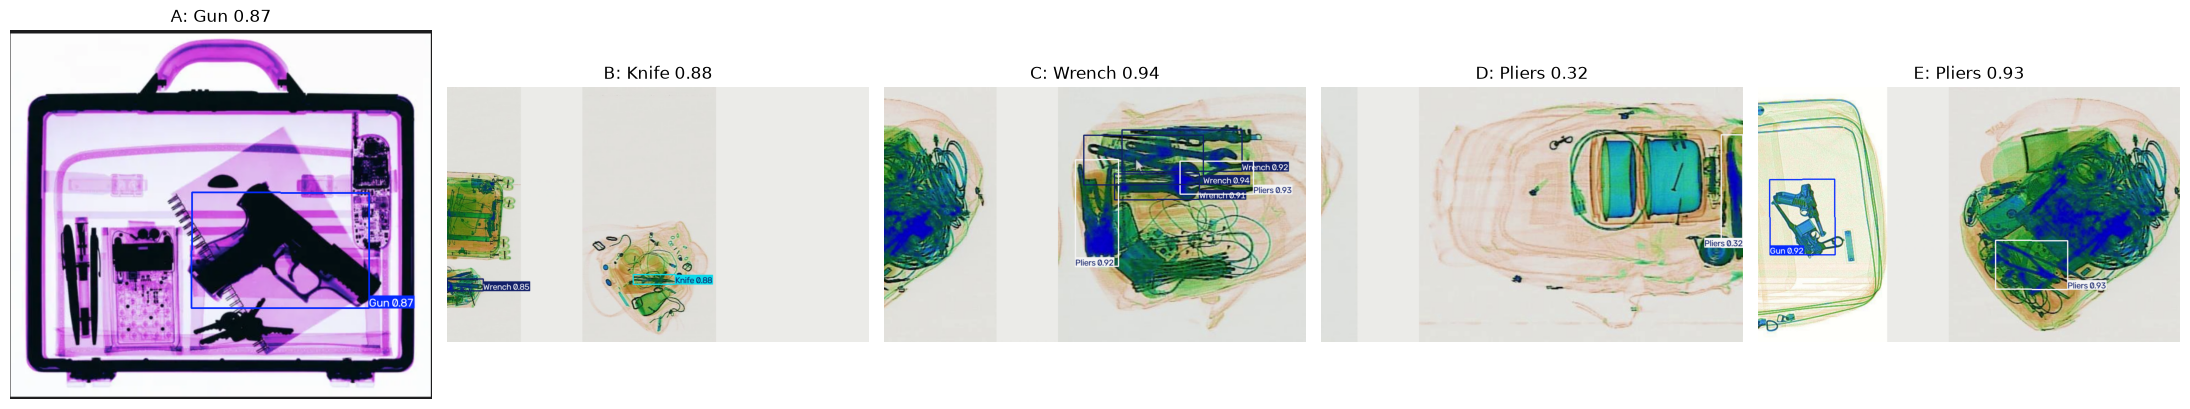

,image,detected,confidence,location
case,,,,
A,test-image.png,Gun,0.8682,Private Aviation Terminal
B,clip 23.0s,Knife,0.8757,LEAP 2026 Exhibition
C,clip 9.5s,Wrench,0.9409,Black Hat MEA
D,clip 13.0s,Pliers,0.3196,Money20/20 Middle East
E,clip 7.0s,Pliers,0.9341,Terminal 5


In [2]:
detector = YoloDetector()  # best_yolov8s.pt, the same detector the app uses


def clip_frame(seconds, path="test_clip.mp4"):
    """One frame of the demo clip. Reads forward rather than seeking, because seeking in a
    compressed video can land on a different frame from one machine to the next."""
    cap = cv2.VideoCapture(path)
    target = round(seconds * cap.get(cv2.CAP_PROP_FPS))
    for _ in range(target + 1):
        ok, frame = cap.read()
    cap.release()
    assert ok, f"{path} has no frame at {seconds}s"
    return frame


EMPLOYEE = {"employee_name": "عبدالله سالم", "employee_id": "SEC-4471"}  # fictional

# "expect" is the class each case was written around; the notes describe that item.
CASES = [
    {"case": "A", "source": "test-image.png", "image": cv2.imread("frontend/public/test-image.png"),
     "expect": "Gun", "location": "Private Aviation Terminal",
     "employee_notes": "فُتحت الحقيبة بحضور صاحبها، ووُجد مسدس في الجيب الداخلي",
     "suspect_phone_number": "0551234567"},
    {"case": "B", "source": "clip 23.0s", "image": clip_frame(23.0),
     "expect": "Knife", "location": "LEAP 2026 Exhibition",
     "employee_notes": "سكين قابلة للطي ملفوفة بقطعة قماش أسفل الحقيبة"},
    {"case": "C", "source": "clip 9.5s", "image": clip_frame(9.5),
     "expect": "Wrench", "location": "Black Hat MEA"},  # no notes and no phone, on purpose
    {"case": "D", "source": "clip 13.0s", "image": clip_frame(13.0),
     "expect": "Pliers", "location": "Money20/20 Middle East",
     "employee_notes": "صورة الأشعة غير واضحة، وأكد التفتيش اليدوي وجود كماشة صغيرة"},
    {"case": "E", "source": "clip 7.0s", "image": clip_frame(7.0),
     "expect": "Pliers", "location": "Terminal 5",  # not a checkpoint, so no scenario on file
     "suspect_name": "سعد ناصر", "suspect_id_number": "1098765432",
     "employee_notes": "كماشة كبيرة بين أدوات عمل"},
]


def incident_data(case):
    """The intake fields for a case, shaped as the dashboard sends them."""
    checkpoint = BY_CODE.get(case["location"])
    data = {
        "location": case["location"],
        "suspect_name": case.get("suspect_name") or checkpoint.suspect.name,
        "suspect_id_number": case.get("suspect_id_number") or checkpoint.suspect.id_number,
        **EMPLOYEE,
        "employee_notes": case.get("employee_notes", ""),
    }
    if "suspect_phone_number" in case:
        data["suspect_phone_number"] = case["suspect_phone_number"]
    return data


for case in CASES:
    # detect() passes its argument straight to Ultralytics, which takes an image array as
    # readily as a path, so the frames never need writing to disk.
    detection = detector.detect(case["image"])
    assert detection.detected_class == case["expect"], (case["case"], detection)
    case["detected_class"], case["confidence"] = detection.detected_class, detection.confidence
    case["data"] = incident_data(case)

# Every box the detector drew; the title is the one detect() passes on.
fig, axes = plt.subplots(1, len(CASES), figsize=(22, 4))
for ax, case in zip(axes, CASES):
    boxed = detector.model.predict(case["image"], verbose=False, device="cpu")[0].plot()
    ax.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{case["case"]}: {case["detected_class"]} {case["confidence"]:.2f}', fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.show()

pd.DataFrame(
    [{"case": c["case"], "image": c["source"], "detected": c["detected_class"],
      "confidence": c["confidence"], "location": c["location"]} for c in CASES]
).set_index("case")

**What the model is not told.** Several frames above hold more than one item, and the report is
written about the most confident one alone. `sample_test_image.png` in the repository is the
extreme case:

In [3]:
result = detector.model.predict("sample_test_image.png", verbose=False, device="cpu")[0]
names = [detector.model.names[int(k)] for k in result.obb.cls.tolist()]
print("Every box:  ", sorted(zip(names, (round(c, 2) for c in result.obb.conf.tolist())), key=lambda b: -b[1]))
print("Passed on:  ", detector.detect("sample_test_image.png"))

Every box:   [('Wrench', 0.92), ('Pliers', 0.9), ('Gun', 0.85), ('Gun', 0.84), ('Gun', 0.83), ('Gun', 0.8), ('Knife', 0.79), ('Gun', 0.74), ('Wrench', 0.32)]
Passed on:   detected_class='Wrench' confidence=0.9153


The bag holds five guns, but the report would be about a wrench, and since routing follows the
class, it would go to airport security rather than the police. The employee sees every box when
verifying, so a person can still catch it, but passing all confirmed boxes to the model is the
clear next step for this pipeline.

## 2. Prompt v1: the first prototype

Nawaf's first report generator (commit `baa79a5`), which ran on Gemini through LangChain. The
prompt is kept as it was, with two changes: the spelling is corrected, and one bug is fixed. The
item was written as `{amount,found}`, which Python formats as a tuple, so the model was told it had
found `('10gm of', 'Drugs')`.

For a fair comparison it runs here on the same model as v2, at the temperature of 0 it originally
used.

What to notice in its design:

- It is given six values, filled into two sentences: checkpoint, receiving authority, item,
  suspect's name, ID number and date. There is no detector confidence, no verification, no employee, notes or
  checkpoint context.
- It tells the model to leave nothing unfilled. That pushes the model to invent whatever is missing
  instead of saying so.
- It does not ask for a language or a structure.

In [4]:
V1_SYSTEM = (
    "You are a security guard in one of Saudi's national airports called {airport} and your role "
    "is to generate reports for {receiver}. This report is going to be sent automatically, make "
    "sure it is ready to send. Do not leave anything like insert this or insert that. We need it "
    "to be ready to send with the info you have."
)
V1_USER = "Create a report, we found a {found} with {name}, his id: {id} and the date is {date}"


def prompt_v1(case):
    data, today = case["data"], checkpoint_now()
    return [
        {"role": "system", "content": V1_SYSTEM.format(
            airport=data["location"], receiver=get_authority_for_class(case["detected_class"]).name)},
        {"role": "user", "content": V1_USER.format(
            found=case["detected_class"], name=data["suspect_name"], id=data["suspect_id_number"],
            date=f"{today.day}/{today.month}/{today.year}")},
    ]


async def complete(messages):
    """One chat completion on the app's text model, at v1's original temperature of 0."""
    async with httpx.AsyncClient(timeout=60) as client:
        response = await client.post(
            "https://api.openai.com/v1/chat/completions",
            headers={"Authorization": f"Bearer {settings.openai_api_key}"},
            json={"model": settings.openai_text_model, "messages": messages, "temperature": 0},
        )
        response.raise_for_status()
        return response.json()["choices"][0]["message"]["content"]


for case in CASES:
    messages = prompt_v1(case)
    start = time.perf_counter()
    case["v1_text"] = await complete(messages)
    case["v1_seconds"] = time.perf_counter() - start
    case["v1_input"] = "\n".join(m["content"] for m in messages)

print(CASES[0]["v1_input"])

You are a security guard in one of Saudi's national airports called Private Aviation Terminal and your role is to generate reports for Police - Armed Response Unit. This report is going to be sent automatically, make sure it is ready to send. Do not leave anything like insert this or insert that. We need it to be ready to send with the info you have.
Create a report, we found a Gun with فيصل فهد, his id: 1093847562 and the date is 18/9/2026


## 3. Prompt v2: production

The prompt the app runs today, called through the app's own code: `generate_report()` in
`agent/report.py` builds the incident record and makes both calls through `OpenAILLMProvider`. The
prompt text itself is in `agent/providers/openai_llm.py`. What changed from v1:

- **The whole incident goes in as JSON**: the detected item and its confidence, the employee's
  verification, the suspect, the employee, the notes, and the checkpoint's scenario.
- **The facts that must not change are named**: the detected item, the confidence and the
  verification status.
- **Missing information is to be stated plainly**, not made up. This reverses v1's instruction.
- **Formal Arabic in five fixed sections**: summary, detection and verification, people involved,
  risk assessment with reasons, and next steps. Saudi responders read it, and the phone call is in
  Arabic too.
- **Severity comes from a separate call that must return only JSON**, with severity limited to four
  values (`low`, `medium`, `high`, `critical`) that the dashboard translates for display. A reply
  that is not valid JSON raises an error instead of reaching the report. The four values are only
  asked for: `IncidentReport.severity` is a plain string, so nothing rejects a fifth.

In [5]:
llm = OpenAILLMProvider()

for case in CASES:
    start = time.perf_counter()
    report, narrative = await generate_report(
        incident_id=new_incident_id(),
        detection_class=case["detected_class"],
        detection_confidence=case["confidence"],
        verification_status="confirmed",  # reports are only written after an employee confirms
        incident_data=case["data"],
        llm=llm,
    )
    case["v2_seconds"] = time.perf_counter() - start  # both calls: severity, then the narrative
    case["v2_text"], case["report"] = narrative, report.model_dump()
    # The narrative call receives exactly this record, severity included.
    case["v2_input"] = json.dumps(case["report"], ensure_ascii=False, default=str)

# Case C, as the model receives it. The scenario comes from the checkpoint, not from the model.
print(json.dumps(CASES[2]["report"], ensure_ascii=False, indent=2))

{
  "incident_id": "INC-20260918-923326",
  "date_time": "2026-09-18T21:54:10.585783+03:00",
  "location": "Black Hat MEA",
  "detected_item": "Wrench",
  "yolo_confidence": 0.9409,
  "verification_status": "confirmed",
  "suspect": {
    "name": "نايف عبدالله",
    "id_number": "1102684759",
    "phone_number": null
  },
  "employee": {
    "name": "عبدالله سالم",
    "id": "SEC-4471"
  },
  "inspection_notes": "",
  "scenario": {
    "الفعالية": "مؤتمر الأمن السيبراني، منطقة الورش والتحديات التقنية",
    "المكان": "مركز المعارض والمؤتمرات، مدخل قاعة الورش",
    "نقطة التفتيش": "بوابة المشاركين رقم 2",
    "الوضع وقت الرصد": "ازدحام مرتفع مع بدء فعاليات الورش",
    "حامل الحقيبة": "مشارك يحمل بطاقة ورشة، أفاد بأن الأدوات تخص ورشة للعتاد الإلكتروني",
    "وصف الحقيبة": "حقيبة أدوات صلبة زرقاء",
    "الإجراءات المتخذة": "عُزلت الحقيبة، ويُتحقق من تسجيله في الورشة مع منظمي المنطقة",
    "مسار وصول الفريق": "من ممر الطوارئ الغربي المؤدي مباشرة إلى بوابة المشاركين",
    "أقرب نقطة أمنية": 

In [6]:
# The JSON call's answers. Nothing in the app checks severity against the four allowed values,
# so this table is where to check it.
pd.DataFrame(
    [{"case": c["case"], "detected": c["detected_class"], "confidence": c["confidence"],
      "severity": c["report"]["severity"], "recommended action": c["report"]["recommended_action"]}
     for c in CASES]
).set_index("case")

,detected,confidence,severity,recommended action
case,,,,
A,Gun,0.8682,critical,يجب اتخاذ إجراء فوري لعزل المشتبه به واستدعاء ...
B,Knife,0.8757,high,يجب اتخاذ إجراءات فورية لمعالجة الوضع والتحقق ...
C,Wrench,0.9409,medium,يجب فحص الأداة المشتبه بها والتأكد من ملاءمتها...
D,Pliers,0.3196,medium,يجب إزالة الكماشة من الحقيبة وعدم السماح بإدخا...
E,Pliers,0.9341,medium,يجب فحص الأدوات الأخرى المسموح بها للتأكد من ع...


## 4. Evaluation

### 4.1 Automatic checks

Cheap checks run on every output, aimed at the mistakes that would do harm in a report that goes to
the police:

- **item named**: the detected item appears, in English or Arabic. Arabic diacritics are removed
  first, so كمّاشة matches كماشة.
- **names**: the suspect's and the employee's names, where the prompt was given them, appear
  exactly. Spaces, diacritics and the spelling variants of alef and yaa are ignored, so عبد الله
  matches عبدالله, but a changed letter is caught.
- **confidence**: whether the detector's confidence appears, as a decimal or a percentage, and
  whether any other confidence-like figure appears instead. v1 is never given the confidence.
- **unsupported numbers**: every number of four or more digits in the report that is not in the
  model's input. Invented ID, phone and flight numbers show up here. Arabic-Indic digits are
  converted first.
- **placeholders**: text such as `[name]` or `insert` left for someone to fill in.
- **Arabic**: the share of letters that are Arabic.

These are string checks. They flag candidates rather than prove anything, so section 4.2 reads the
outputs themselves.

In [7]:
ITEM_WORDS = {  # the class name, plus the words a report is likely to use for it
    "Gun": ["gun", "pistol", "firearm", "handgun", "سلاح ناري", "مسدس"],
    "Knife": ["knife", "سكين"],
    "Pliers": ["pliers", "كماشة", "زردية"],
    "Scissors": ["scissors", "مقص"],
    "Wrench": ["wrench", "spanner", "مفتاح"],
}
TO_ASCII = str.maketrans({**{a: str(i) for i, a in enumerate("٠١٢٣٤٥٦٧٨٩")}, "٫": "."})
DIACRITICS = re.compile(r"[ً-ْـ]")  # harakat, shadda, sukun and tatweel
PLACEHOLDER = re.compile(r"\[[^\]]{1,40}\]|\binsert\b|<[^>]{1,40}>|X{3,}|_{3,}", re.IGNORECASE)
PERCENT = re.compile(r"(\d{1,3}(?:\.\d+)?)\s*(?:%|٪|بالمئة|بالمائة|في المئة|percent)")


def name_key(text):
    """A name with spaces, diacritics and the spelling variants of alef and yaa removed, so
    عبد الله matches عبدالله but سعيد does not match سعد."""
    text = DIACRITICS.sub("", text).translate(str.maketrans("أإآى", "اااي"))
    return re.sub(r"\s+", "", text)


def names_check(text, case, source):
    """'kept', or the names from the model's input that the report does not repeat exactly."""
    names = [case["data"]["suspect_name"], case["data"]["employee_name"]]
    missing = [n for n in names if n in source and name_key(n) not in name_key(text)]
    return f"changed: {', '.join(missing)}" if missing else "kept"


def confidence_check(text, confidence):
    """'stated', 'not stated', or the figures given in its place."""
    figures = [float(x) for x in re.findall(r"\b0\.\d+", text)]
    figures += [float(x) / 100 for x in PERCENT.findall(text)]
    if any(abs(f - confidence) < 0.006 for f in figures):
        return "stated"
    return f"other: {figures}" if figures else "not stated"


def checks(case, version):
    text = DIACRITICS.sub("", case[f"{version}_text"]).translate(TO_ASCII)
    source = case[f"{version}_input"].translate(TO_ASCII)
    arabic = len(re.findall(r"[؀-ۿ]", text))
    latin = len(re.findall(r"[A-Za-z]", text))
    return {
        "case": case["case"],
        "prompt": version,
        "item named": any(w in text.lower() for w in ITEM_WORDS[case["detected_class"]]),
        "names": names_check(text, case, source),
        "confidence": confidence_check(text, case["confidence"]),
        "unsupported numbers": ", ".join(sorted({n for n in re.findall(r"\d{4,}", text) if n not in source})) or "none",
        "placeholders": ", ".join(sorted(set(PLACEHOLDER.findall(text)))) or "none",
        "Arabic": f"{arabic / max(arabic + latin, 1):.0%}",
        "characters": len(case[f"{version}_text"]),
        "seconds": round(case[f"{version}_seconds"], 1),
    }


pd.set_option("display.max_colwidth", 60)
pd.DataFrame([checks(c, v) for v in ("v1", "v2") for c in CASES]).set_index(["prompt", "case"])

item named                            names  confidence  \
prompt case                                                            
v1     A           True                             kept  not stated   
       B           True                             kept  not stated   
       C           True                             kept  not stated   
       D           True                             kept  not stated   
       E           True                             kept  not stated   
v2     A           True                             kept      stated   
       B           True                             kept      stated   
       C           True                             kept      stated   
       D           True                             kept      stated   
       E           True  changed: سعد ناصر, عبدالله سالم      stated   

            unsupported numbers                                 placeholders  \
prompt case                                                                    
v1     A                   none                                  [Your Name]   
       B                   none  Insert, [Insert size if known], [Your Name]   
       C                   none                        [Security Guard Name]   
       D                   none                                  [Your Name]   
       E                   none                                  [Your Name]   
v2     A                   none                                         none   
       B                   none                                         none   
       C                   none                                         none   
       D                   none                                         none   
       E                   none                                         none   

            Arabic  characters  seconds  
prompt case                              
v1     A        2%        1144      5.1  
       B        3%        1185      4.7  
       C        5%         673      2.7  
       D        3%         869      5.2  
       E        3%         762      6.0  
v2     A      100%        1902     11.4  
       B      100%        1812      7.8  
       C      100%        1878      9.0  
       D       99%        1945      9.2  
       E      100%        1926      7.8

### 4.2 Reading the outputs

Every report from both prompts, case by case. v2's `seconds` above covers two calls, the severity
JSON and the narrative.

In [8]:
def show(title, text):
    display(HTML(
        f"<h4>{html.escape(title)}</h4>"
        f"<div dir='auto' style='white-space: pre-wrap; border-inline-start: 3px solid #999; "
        f"padding-inline-start: 12px'>{html.escape(text)}</div>"
    ))


for case in CASES:
    label = f'Case {case["case"]}: {case["detected_class"]} {case["confidence"]:.2f} at {case["location"]}'
    show(f"{label}, prompt v1", case["v1_text"])
    show(f"{label}, prompt v2", case["v2_text"])

### 4.3 What reading them found

Every report above was read against its input, including the checkpoint scenario in
`agent/checkpoints.py`.

| | Prompt v1 | Prompt v2 |
|---|---|---|
| Item named correctly | 5 of 5 | 5 of 5 |
| Detector confidence stated | 0 of 5 (never given it) | 5 of 5 |
| Placeholders left | 5 of 5 | 0 of 5 |
| Invented actions | 5 of 5 | 1 of 5 |
| Names changed | 0 of 5 | 1 of 5 |
| Language | English | Arabic |
| Seconds per report | about 3 to 6 (one call) | about 8 to 11 (two calls) |

**Prompt v1** failed the same way in every case:

- **A placeholder in every report.** `[Your Name]` or `[Security Guard Name]` for the author, and in
  case B two more, such as `[Insert size if known]`, although the prompt forbids exactly that. It is
  never told who the employee is.
- **Invented actions.** Case A says the individual "has been detained and is awaiting the arrival of
  the Armed Response Unit", case B that he "was detained for questioning" and that local authorities
  were notified, and case D puts the pliers in "the airport's lost and found department". None of
  this is in the input.
- **Event venues become airports**: "Black Hat MEA Airport" and "Money20/20 Middle East Airport",
  because the prompt says the guard works at one.
- It never mentions the detector, its confidence or the employee's check, having been given none
  of them, and it writes in English.

**Prompt v2** kept the facts that decide the response:

- The item and the detector's confidence are right in all five, including case D's 31.96%.
- No invented ID or phone numbers. Case A reports the phone number it was given. Of the four with
  none, C, D and E say so and B leaves it out.
- With no scenario on file (case E), it does not invent an event, gate or crowd.
- Severity follows the item: critical for the gun, high for the knife, medium for the wrench and
  both pliers. For the pliers the detector was unsure of (D), the risk assessment says the
  confidence is not high.
- Where a scenario was on file, its details mostly come through correctly: the gate, the crowd,
  the bag, and what staff had already done.

It still made mistakes, and the worst are exactly what its prompt forbids:

- **An invented action.** Case E says the find "led to opening an immediate investigation"
  (فتح تحقيق فوري), and that the pliers are classed as dangerous and not allowed. Neither is in
  the input.
- **An invented inference.** Case A says the bag's contents and the way the gun was stored "confirm
  a possible intent to use it" (يؤكدان نية محتملة لاستخدامه). Nothing in the input supports that.
- **The wrong word for the item.** Case C calls the wrench a lever (أداة رافعة), naming the wrench
  (مفتاح ربط) only in brackets.
- **Changed names.** Case E writes the suspect as سعيد ناصر instead of سعد ناصر, and the employee
  as عبد لله سالم. The names check caught both; no other check would have.
- **Garbled words.** Case A calls the bag الطالبة (the female student), case D calls the X-ray
  image "the archival image" (الصورة الأرشيفية), and case C says the tools "were prepared and
  active".
- **Distortions.** Case A moves the find from the VIP reception to a business-aircraft reception,
  case B drops that the knife was a folding one, and case D recommends contacting the booth
  management, which the scenario records as already done.

Earlier runs of this notebook, with the same prompts, slipped in other places: one invented an
arrest, another recommended searching the bag for a screwdriver when the item was a wrench, and
the same misspelling of case E's suspect (سعيد for سعد) appeared in an earlier run too. The errors
land at random, so one clean run proves little.

### 4.4 What this means for the app

- **v2 is the right design.** The facts that decide the response come through: the item, the
  confidence, who, and where. It usually says what it does not know instead of filling the gap. v1's
  prompt invites invention; v2's forbids it and mostly succeeds.
- **The narrative is not reliable enough to act on unread, and the app does not act on it.** The
  record sent to the authority's endpoint is the structured report, not the narrative, and the
  phone call's briefing is built from the same structured fields (`agent/voice/authority_prompts.py`).
  An invented investigation or a misspelled name in the narrative reaches the dashboard, where the
  employee can read it, but not the call or the authority's record.
- **Two model outputs are not protected that way.** `severity` and `recommended_action` go into the
  structured record as the model wrote them. The prompt asks for one of four severities, and all
  five answers here were valid, but the code does not enforce it. The recommended action is free
  text: in an earlier run, case C's named a screwdriver for a wrench.

### 4.5 Limitations and next steps

- **A small sample.** Five cases and one saved run show the kinds of error, not how often they
  happen. Measuring rates would mean running each case many times and counting.
- **The automatic checks are partial.** They catch changed names, numbers, placeholders and a
  missing item or confidence. The invented investigation, the invented inference and the wrong word
  for the wrench needed a person reading.
- **Arabic reaches the model escaped.** `agent/providers/openai_llm.py` serialises the record with
  `json.dumps` defaults, so every Arabic character in names, notes and scenarios arrives as a
  `\uXXXX` escape. The model decodes them, but it costs far more tokens and is a plausible cause of
  letter-level slips like the changed names. Passing `ensure_ascii=False` is a one-line change
  worth testing with this notebook.
- **The model sees one detection per image** (section 1).

Worth testing next with this notebook: `ensure_ascii=False`, a lower temperature (the app uses the
API default), and a recommended action chosen from a fixed list per class instead of written
freely.